<a href="https://colab.research.google.com/github/MarianaCelisBougard/Taller_NNA_Grupo4/blob/main/Evaluation_%20Deployment/Evaluation_Deployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
# -*- coding: utf-8 -*-
"""
==============================================================================
CRISP-DM FASE 5: EVALUATION - INTERPRETACIÓN Y EVALUACIÓN DE RESULTADOS
Proyecto: Caracterización de NNA en Programas de Intervención
Notebook 4 de 4 - Evaluación e Interpretación Final
==============================================================================
"""
# ==============================================================================
# 1. CONFIGURACIÓN INICIAL
# ==============================================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración visual mejorada
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11

print("=" * 80)
print("CRISP-DM FASE 5: EVALUATION - INTERPRETACIÓN Y EVALUACIÓN")
print("Proyecto: Caracterización de NNA en Trabajo Infantil")
print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CRISP-DM FASE 5: EVALUATION - INTERPRETACIÓN Y EVALUACIÓN
Proyecto: Caracterización de NNA en Trabajo Infantil
Fecha de ejecución: 2025-10-16 20:35:10


In [80]:
# ==============================================================================
# 2. CARGA DE DATOS CON CLUSTERS
# ==============================================================================

ruta_datos = '/content/drive/MyDrive/Python/Proyecto NNA/'

print("\n📂 Cargando datos con clusters asignados...")
datos_clustered = pd.read_csv(ruta_datos + 'datos_con_clusters_LIMPIO.csv')
coords_factoriales = pd.read_csv(ruta_datos + 'coordenadas_factoriales.csv')
resultados_mca = pd.read_excel(ruta_datos + 'resultados_mca.xlsx')

# ✓ MODIFICACIÓN CRÍTICA: Convertir CLUSTER a string para mapeo correcto
datos_clustered['CLUSTER'] = datos_clustered['CLUSTER'].astype(str)

print(f"✅ Datos cargados exitosamente")
print(f"   - NNA con perfiles: {len(datos_clustered):,}")
print(f"   - Variables analizadas: {datos_clustered.shape[1] - 1}")
print(f"   - Número de perfiles: {datos_clustered['CLUSTER'].nunique()}")


📂 Cargando datos con clusters asignados...
✅ Datos cargados exitosamente
   - NNA con perfiles: 56,473
   - Variables analizadas: 21
   - Número de perfiles: 4


In [81]:
# ==============================================================================
# 3. INTERPRETACIÓN PROFUNDA DE PERFILES
# ==============================================================================

print("\n" + "=" * 80)
print("🔍 INTERPRETACIÓN PROFUNDA DE PERFILES")
print("=" * 80)

# Definir nombres interpretativos para cada perfil
nombres_perfiles = {
    '0': 'P1: Intervención Exitosa Documentada',
    '1': 'P2: Registro Administrativo Incompleto',
    '2': 'P3: Seguimiento Inconcluso',
    '3': 'P4: Casos Sin Cierre Documentado'
}

# Mapear nombres
datos_clustered['PERFIL_NOMBRE'] = datos_clustered['CLUSTER'].map(nombres_perfiles)

print("\n📊 Distribución de perfiles:")
for cluster, nombre in nombres_perfiles.items():
    n = sum(datos_clustered['CLUSTER'] == cluster)
    pct = n / len(datos_clustered) * 100
    print(f"   {nombre}: {n:,} NNA ({pct:.1f}%)")

# 3.1 Análisis detallado por perfil
print("\n" + "=" * 80)
print("📋 CARACTERIZACIÓN DETALLADA POR PERFIL")
print("=" * 80)

variables_clave = [
    'SEXO', 'EDAD_GRUPO', 'ESTRATO', 'NACIONALIDAD',
    'TIPO INTERVENCIÓN', 'ZONA', 'OCUPACIÓN',
    'NNA DESVINCULADO DE LA ACTIVIDAD LABORAL',
    'INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO'
]

# Filtrar variables disponibles
vars_disponibles = [v for v in variables_clave if v in datos_clustered.columns]

for cluster_id, nombre_perfil in nombres_perfiles.items():
    print("\n" + "=" * 80)
    print(f"{nombre_perfil.upper()}")
    print("=" * 80)

    datos_perfil = datos_clustered[datos_clustered['CLUSTER'] == cluster_id]
    n_perfil = len(datos_perfil)
    pct_perfil = n_perfil / len(datos_clustered) * 100

    print(f"\n📊 Tamaño: {n_perfil:,} NNA ({pct_perfil:.1f}% del total)")

    # Analizar cada variable
    for var in vars_disponibles:
        print(f"\n📌 {var}:")

        # Frecuencias
        freq = datos_perfil[var].value_counts()
        freq_pct = datos_perfil[var].value_counts(normalize=True) * 100

        # Mostrar top 5
        for i, (cat, count) in enumerate(freq.head(5).items()):
            pct = freq_pct.iloc[i]
            print(f"   {i+1}. {cat}: {count:,} ({pct:.1f}%)")

        # Indicador de completitud
        no_reporta_pct = (datos_perfil[var] == 'No_reporta').sum() / n_perfil * 100
        if no_reporta_pct > 50:
            print(f"   ⚠️ Alta incompletitud: {no_reporta_pct:.1f}% sin datos")
        elif no_reporta_pct > 0:
            print(f"   ℹ️ Datos faltantes: {no_reporta_pct:.1f}%")
        else:
            print(f"   ✅ Completitud: 100%")

    print("\n" + "-" * 80)



🔍 INTERPRETACIÓN PROFUNDA DE PERFILES

📊 Distribución de perfiles:
   P1: Intervención Exitosa Documentada: 23,672 NNA (41.9%)
   P2: Registro Administrativo Incompleto: 20,065 NNA (35.5%)
   P3: Seguimiento Inconcluso: 4,661 NNA (8.3%)
   P4: Casos Sin Cierre Documentado: 8,075 NNA (14.3%)

📋 CARACTERIZACIÓN DETALLADA POR PERFIL

P1: INTERVENCIÓN EXITOSA DOCUMENTADA

📊 Tamaño: 23,672 NNA (41.9% del total)

📌 SEXO:
   1. 1- Hombre: 12,098 (51.1%)
   2. 2- Mujer: 11,574 (48.9%)
   ✅ Completitud: 100%

📌 EDAD_GRUPO:
   1. 6-10_Infancia: 8,081 (34.1%)
   2. 0-5_Primera_Infancia: 6,425 (27.1%)
   3. 11-14_Preadolescencia: 6,039 (25.5%)
   4. 15-18_Adolescencia: 3,127 (13.2%)
   ✅ Completitud: 100%

📌 ESTRATO:
   1. 2. Bajo: 15,394 (65.0%)
   2. 3. Medio-bajo: 4,429 (18.7%)
   3. 1. Bajo-bajo: 3,835 (16.2%)
   4. Otros_ESTRATO: 13 (0.1%)
   5. No_reporta: 1 (0.0%)
   ℹ️ Datos faltantes: 0.0%

📌 NACIONALIDAD:
   1. Colombia: 19,481 (82.3%)
   2. Venezuela (Bolivarian Republic of): 4,160 (17


📊 ANÁLISIS COMPARATIVO ENTRE PERFILES

🎯 Análisis de éxito de intervención (Desvinculación):

--------------------------------------------------------------------------------
NNA DESVINCULADO DE LA ACTIVIDAD LABORAL    NO  No_reporta  \
CLUSTER                                                      
P1: Éxito Documentado                     19.1         3.6   
P2: Registro Incompleto                   13.6         2.7   
P3: Seguimiento Inconcluso                 0.0        57.6   
P4: Sin Cierre                             0.0       100.0   

NNA DESVINCULADO DE LA ACTIVIDAD LABORAL  Otros_NNA DESVINCULADO DE    SI  \
CLUSTER                                                                     
P1: Éxito Documentado                                           0.1  77.3   
P2: Registro Incompleto                                         0.1  83.6   
P3: Seguimiento Inconcluso                                      9.0   0.0   
P4: Sin Cierre                                                  0.

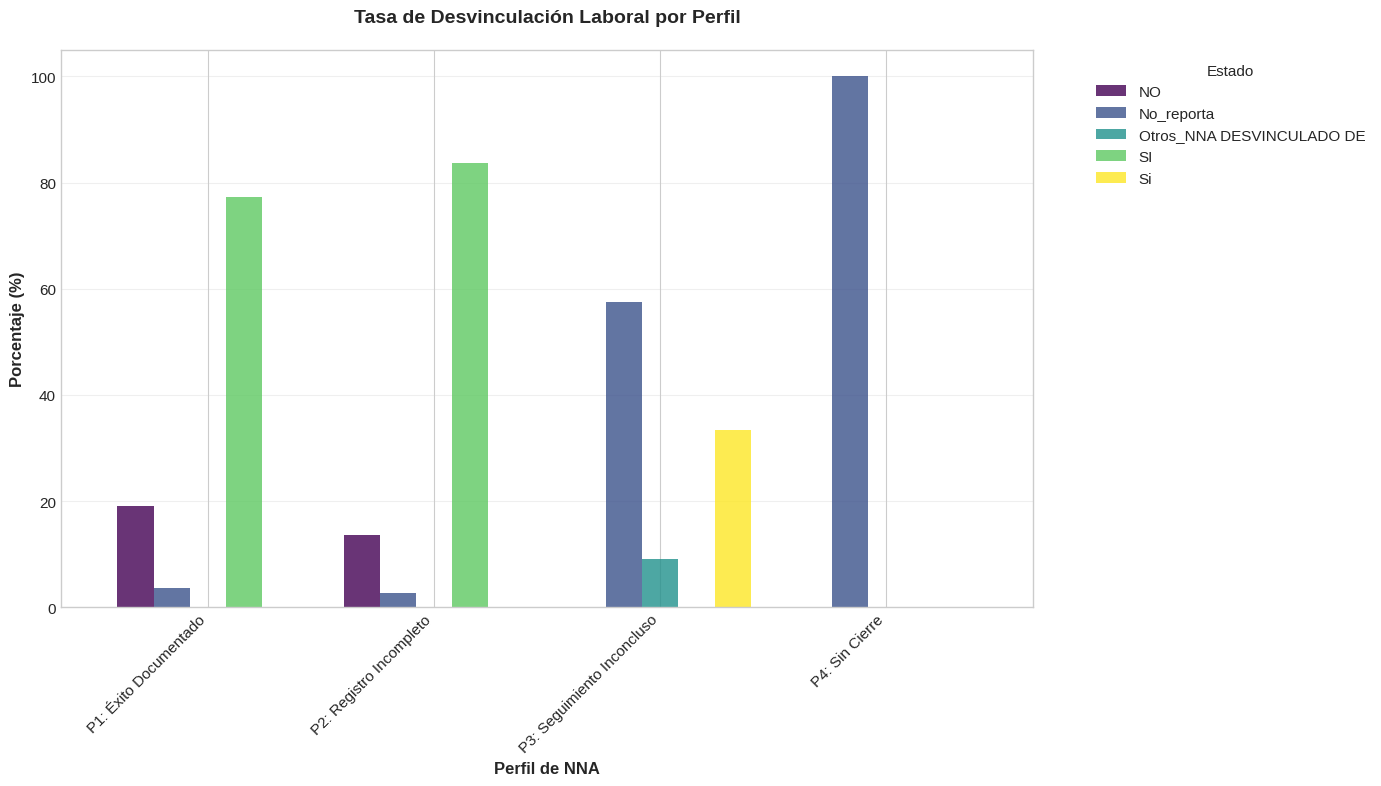


📈 Tasa de éxito efectiva (excluyendo casos sin reporte):
   P1: Éxito Documentado: 80.2% (n=22,809)
   P2: Registro Incompleto: 86.0% (n=19,510)
   P3: Seguimiento Inconcluso: Sin datos suficientes
   P4: Sin Cierre: Sin datos suficientes

👥 ANÁLISIS DEMOGRÁFICO COMPARATIVO


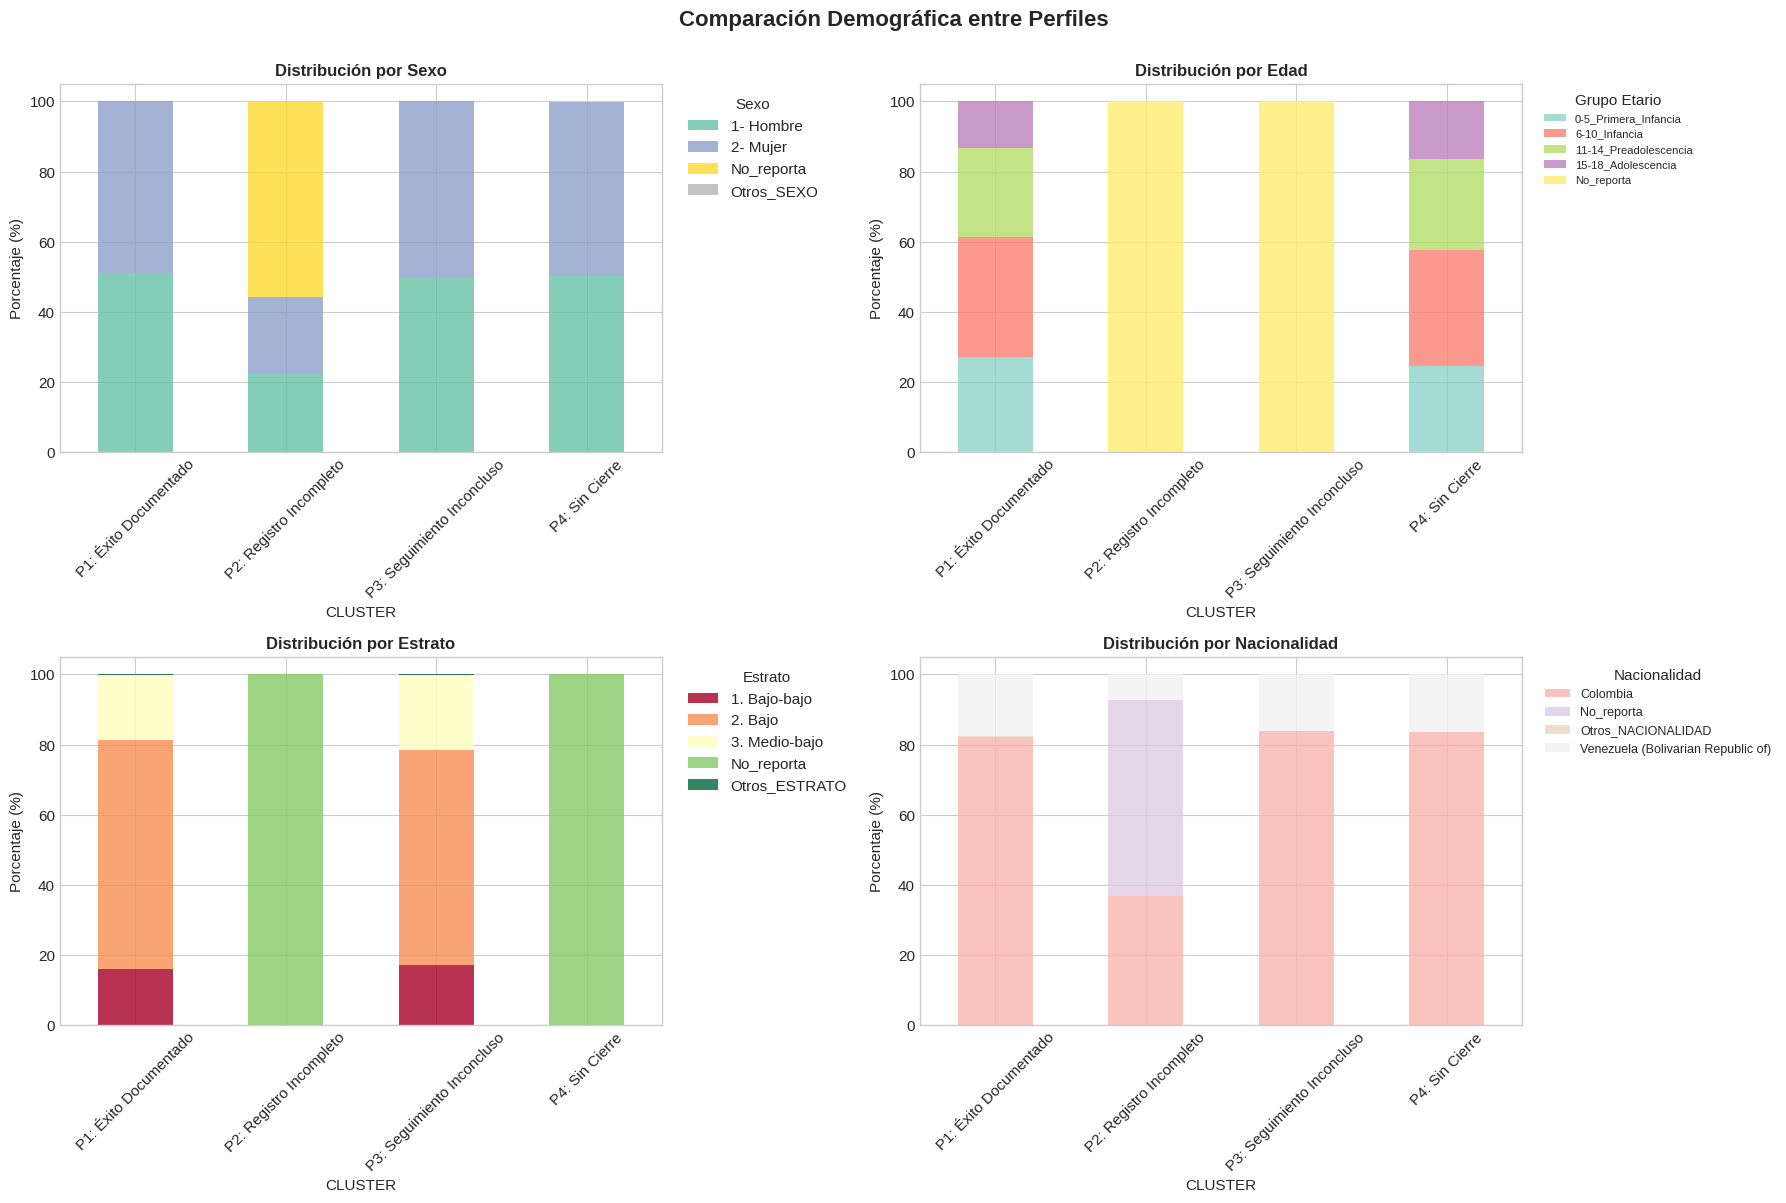

✓ Secciones 3 y 4 completadas exitosamente


In [82]:
# ==============================================================================
# 4. ANÁLISIS COMPARATIVO ENTRE PERFILES
# ==============================================================================

print("\n" + "=" * 80)
print("📊 ANÁLISIS COMPARATIVO ENTRE PERFILES")
print("=" * 80)

# 4.1 Variable crítica: Desvinculación laboral
var_desvinculacion = 'NNA DESVINCULADO DE LA ACTIVIDAD LABORAL'

if var_desvinculacion in datos_clustered.columns:
    print(f"\n🎯 Análisis de éxito de intervención (Desvinculación):")
    print("\n" + "-" * 80)

    # Usar CLUSTER en lugar de PERFIL_NOMBRE para crosstab
    tabla_desvinculacion = pd.crosstab(
        datos_clustered['CLUSTER'],
        datos_clustered[var_desvinculacion],
        normalize='index'
    ) * 100

    # Renombrar índices con nombres descriptivos
    cluster_nombres_cortos = {
        '0': 'P1: Éxito Documentado',
        '1': 'P2: Registro Incompleto',
        '2': 'P3: Seguimiento Inconcluso',
        '3': 'P4: Sin Cierre'
    }
    tabla_desvinculacion.index = tabla_desvinculacion.index.map(cluster_nombres_cortos)

    print(tabla_desvinculacion.round(1))

    # Verificar que hay datos antes de plotear
    if not tabla_desvinculacion.empty and len(tabla_desvinculacion.columns) > 0:
        # Visualización
        fig, ax = plt.subplots(figsize=(14, 8))
        tabla_desvinculacion.plot(kind='bar', ax=ax, width=0.8, alpha=0.8, colormap='viridis')
        ax.set_xlabel('Perfil de NNA', fontsize=12, fontweight='bold')
        ax.set_ylabel('Porcentaje (%)', fontsize=12, fontweight='bold')
        ax.set_title('Tasa de Desvinculación Laboral por Perfil',
                     fontsize=14, fontweight='bold', pad=20)
        ax.legend(title='Estado', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3, axis='y')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("\n⚠️ No hay suficientes datos para generar el gráfico")

    # Calcular tasa de éxito efectiva (excluyendo No_reporta)
    print("\n📈 Tasa de éxito efectiva (excluyendo casos sin reporte):")
    for cluster_id in ['0', '1', '2', '3']:
        datos_perfil = datos_clustered[datos_clustered['CLUSTER'] == cluster_id]
        nombre_perfil = cluster_nombres_cortos[cluster_id]

        # Filtrar solo casos con resultado documentado
        con_resultado = datos_perfil[
            (datos_perfil[var_desvinculacion] == 'SI') |
            (datos_perfil[var_desvinculacion] == 'NO')
        ]

        if len(con_resultado) > 0:
            tasa_exito = (con_resultado[var_desvinculacion] == 'SI').sum() / len(con_resultado) * 100
            n_base = len(con_resultado)
            print(f"   {nombre_perfil}: {tasa_exito:.1f}% (n={n_base:,})")
        else:
            print(f"   {nombre_perfil}: Sin datos suficientes")

# 4.2 Análisis demográfico comparativo
print("\n" + "=" * 80)
print("👥 ANÁLISIS DEMOGRÁFICO COMPARATIVO")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# SEXO
if 'SEXO' in datos_clustered.columns:
    tabla_sexo = pd.crosstab(
        datos_clustered['CLUSTER'],
        datos_clustered['SEXO'],
        normalize='index'
    ) * 100

    # Renombrar índices
    tabla_sexo.index = tabla_sexo.index.map(cluster_nombres_cortos)

    tabla_sexo.plot(kind='bar', ax=axes[0, 0], stacked=True, alpha=0.8, colormap='Set2')
    axes[0, 0].set_title('Distribución por Sexo', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Porcentaje (%)')
    axes[0, 0].legend(title='Sexo', bbox_to_anchor=(1.02, 1))
    axes[0, 0].tick_params(axis='x', rotation=45)

# EDAD_GRUPO
if 'EDAD_GRUPO' in datos_clustered.columns:
    tabla_edad = pd.crosstab(
        datos_clustered['CLUSTER'],
        datos_clustered['EDAD_GRUPO'],
        normalize='index'
    ) * 100

    # Renombrar índices
    tabla_edad.index = tabla_edad.index.map(cluster_nombres_cortos)

    orden_edad = ['0-5_Primera_Infancia', '6-10_Infancia', '11-14_Preadolescencia',
                  '15-18_Adolescencia', '18+_Joven', 'No_reporta']
    cols_disponibles = [c for c in orden_edad if c in tabla_edad.columns]
    tabla_edad = tabla_edad[cols_disponibles]

    tabla_edad.plot(kind='bar', ax=axes[0, 1], stacked=True, alpha=0.8, colormap='Set3')
    axes[0, 1].set_title('Distribución por Edad', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Porcentaje (%)')
    axes[0, 1].legend(title='Grupo Etario', bbox_to_anchor=(1.02, 1), fontsize=8)
    axes[0, 1].tick_params(axis='x', rotation=45)

# ESTRATO
if 'ESTRATO' in datos_clustered.columns:
    tabla_estrato = pd.crosstab(
        datos_clustered['CLUSTER'],
        datos_clustered['ESTRATO'],
        normalize='index'
    ) * 100

    # Renombrar índices
    tabla_estrato.index = tabla_estrato.index.map(cluster_nombres_cortos)

    tabla_estrato.plot(kind='bar', ax=axes[1, 0], stacked=True, alpha=0.8, colormap='RdYlGn')
    axes[1, 0].set_title('Distribución por Estrato', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Porcentaje (%)')
    axes[1, 0].legend(title='Estrato', bbox_to_anchor=(1.02, 1))
    axes[1, 0].tick_params(axis='x', rotation=45)

# NACIONALIDAD
if 'NACIONALIDAD' in datos_clustered.columns:
    tabla_nac = pd.crosstab(
        datos_clustered['CLUSTER'],
        datos_clustered['NACIONALIDAD'],
        normalize='index'
    ) * 100

    # Renombrar índices
    tabla_nac.index = tabla_nac.index.map(cluster_nombres_cortos)

    tabla_nac.plot(kind='bar', ax=axes[1, 1], stacked=True, alpha=0.8, colormap='Pastel1')
    axes[1, 1].set_title('Distribución por Nacionalidad', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Porcentaje (%)')
    axes[1, 1].legend(title='Nacionalidad', bbox_to_anchor=(1.02, 1), fontsize=9)
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Comparación Demográfica entre Perfiles',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("=" * 80)
print("✓ Secciones 3 y 4 completadas exitosamente")
print("=" * 80)


📊 ANÁLISIS DE CALIDAD DE DATOS POR PERFIL

📋 Completitud de datos por perfil (%):
                             SEXO  EDAD_GRUPO  ESTRATO  NACIONALIDAD  \
P1: Éxito Documentado       100.0       100.0    100.0         100.0   
P2: Registro Incompleto      44.3         0.0      0.0          44.3   
P3: Seguimiento Inconcluso  100.0         0.0    100.0         100.0   
P4: Sin Cierre              100.0       100.0      0.0         100.0   

                            TIPO INTERVENCIÓN   ZONA  OCUPACIÓN  \
P1: Éxito Documentado                   100.0  100.0      100.0   
P2: Registro Incompleto                  99.9   92.3        0.0   
P3: Seguimiento Inconcluso              100.0  100.0      100.0   
P4: Sin Cierre                            0.0    0.0       97.4   

                            NNA DESVINCULADO DE LA ACTIVIDAD LABORAL  \
P1: Éxito Documentado                                           96.4   
P2: Registro Incompleto                                         97.3   
P3: 

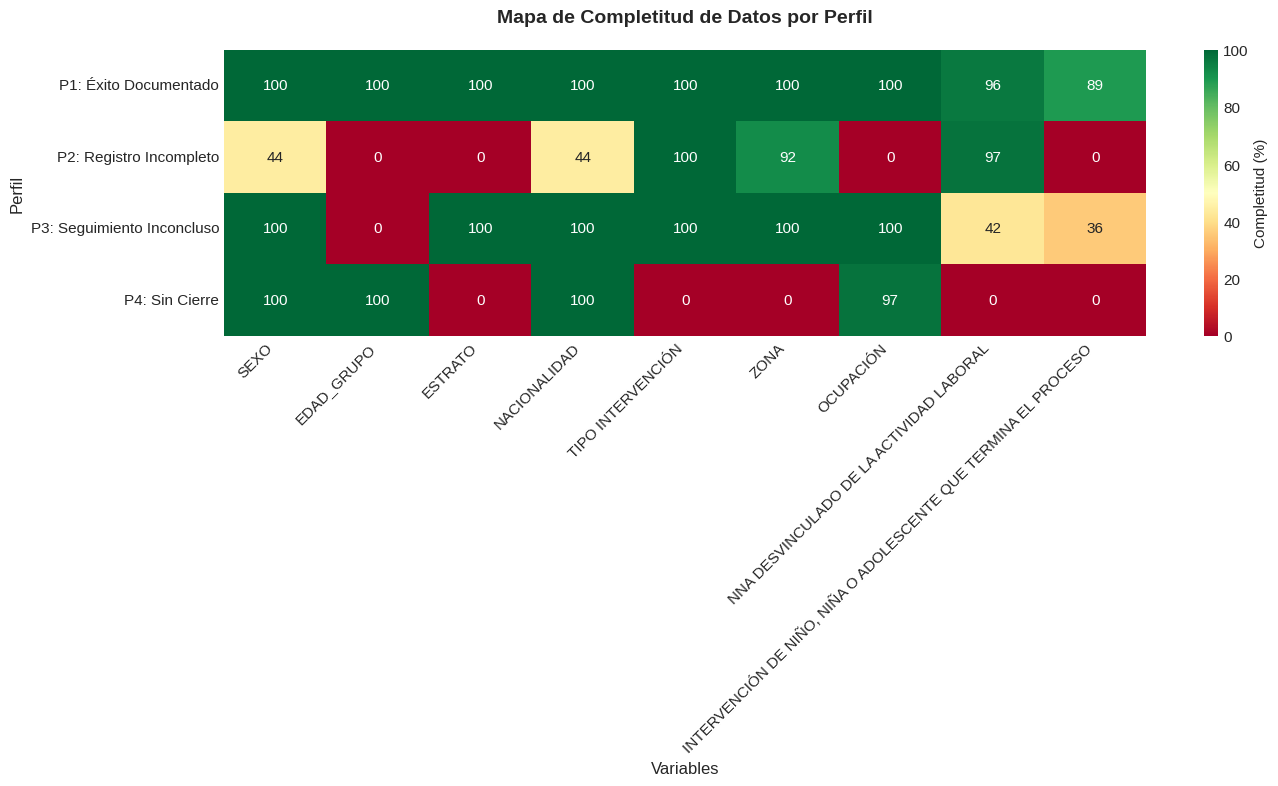


🎯 Índice de Calidad de Datos por Perfil:
                            ÍNDICE_CALIDAD
P1: Éxito Documentado                 98.4
P3: Seguimiento Inconcluso            75.4
P4: Sin Cierre                        44.2
P2: Registro Incompleto               42.0


In [83]:
# ==============================================================================
# 5. ANÁLISIS DE CALIDAD DE DATOS POR PERFIL
# ==============================================================================

print("\n" + "=" * 80)
print("📊 ANÁLISIS DE CALIDAD DE DATOS POR PERFIL")
print("=" * 80)

# Calcular completitud por perfil y variable
completitud = {}

for cluster_id in ['0', '1', '2', '3']:
    datos_perfil = datos_clustered[datos_clustered['CLUSTER'] == cluster_id]
    nombre_perfil = cluster_nombres_cortos[cluster_id]

    completitud_perfil = {}
    for var in vars_disponibles:
        pct_completo = ((datos_perfil[var] != 'No_reporta').sum() / len(datos_perfil)) * 100
        completitud_perfil[var] = pct_completo

    completitud[nombre_perfil] = completitud_perfil

# Crear DataFrame
df_completitud = pd.DataFrame(completitud).T
df_completitud = df_completitud.round(1)

print("\n📋 Completitud de datos por perfil (%):")
print(df_completitud)

# Visualización heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(df_completitud, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=0, vmax=100, cbar_kws={'label': 'Completitud (%)'})
plt.title('Mapa de Completitud de Datos por Perfil',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Variables', fontsize=12)
plt.ylabel('Perfil', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Indicador global de calidad por perfil
print("\n🎯 Índice de Calidad de Datos por Perfil:")
df_completitud['ÍNDICE_CALIDAD'] = df_completitud.mean(axis=1).round(1)
df_calidad = df_completitud[['ÍNDICE_CALIDAD']].sort_values('ÍNDICE_CALIDAD', ascending=False)
print(df_calidad)

In [84]:
# ==============================================================================
# 6. IDENTIFICACIÓN DE FACTORES DE RIESGO
# ==============================================================================

print("\n" + "=" * 80)
print("⚠️ IDENTIFICACIÓN DE FACTORES DE RIESGO")
print("=" * 80)

# Analizar asociación entre variables y desvinculación exitosa
if var_desvinculacion in datos_clustered.columns:

    # Filtrar solo casos con resultado documentado
    datos_validos = datos_clustered[
        (datos_clustered[var_desvinculacion] == 'SI') |
        (datos_clustered[var_desvinculacion] == 'NO')
    ].copy()

    datos_validos['DESVINCULADO_BIN'] = (datos_validos[var_desvinculacion] == 'SI').astype(int)

    print(f"\n📊 Casos con resultado documentado: {len(datos_validos):,}")
    print(f"   Desvinculados: {datos_validos['DESVINCULADO_BIN'].sum():,} ({datos_validos['DESVINCULADO_BIN'].mean()*100:.1f}%)")

    # Analizar tasa de éxito por variables clave
    factores_analisis = ['SEXO', 'EDAD_GRUPO', 'ESTRATO', 'NACIONALIDAD', 'ZONA']
    factores_disponibles = [f for f in factores_analisis if f in datos_validos.columns]

    print("\n🔍 Tasa de desvinculación por factor:")

    for factor in factores_disponibles:
        print(f"\n📌 {factor}:")

        # Excluir 'No_reporta' para análisis limpio
        datos_factor = datos_validos[datos_validos[factor] != 'No_reporta']

        if len(datos_factor) > 0:
            tasas = datos_factor.groupby(factor)['DESVINCULADO_BIN'].agg(['mean', 'count'])
            tasas['mean'] = tasas['mean'] * 100
            tasas = tasas.sort_values('mean', ascending=False)
            tasas.columns = ['Tasa_Éxito_%', 'N']

            print(tasas.round(1))

            # Identificar grupos de riesgo (tasa < promedio)
            promedio = datos_factor['DESVINCULADO_BIN'].mean() * 100
            grupos_riesgo = tasas[tasas['Tasa_Éxito_%'] < promedio]

            if len(grupos_riesgo) > 0:
                print(f"\n   ⚠️ Grupos con menor tasa de éxito (< {promedio:.1f}%):")
                for idx, row in grupos_riesgo.iterrows():
                    print(f"      • {idx}: {row['Tasa_Éxito_%']:.1f}% (n={int(row['N']):,})")



⚠️ IDENTIFICACIÓN DE FACTORES DE RIESGO

📊 Casos con resultado documentado: 42,319
   Desvinculados: 35,071 (82.9%)

🔍 Tasa de desvinculación por factor:

📌 SEXO:
           Tasa_Éxito_%      N
SEXO                          
2- Mujer           82.0  15473
1- Hombre          81.4  16033

   ⚠️ Grupos con menor tasa de éxito (< 81.7%):
      • 1- Hombre: 81.4% (n=16,033)

📌 EDAD_GRUPO:
                       Tasa_Éxito_%     N
EDAD_GRUPO                               
11-14_Preadolescencia          83.2  5819
6-10_Infancia                  81.8  7804
0-5_Primera_Infancia           78.2  6173
15-18_Adolescencia             74.5  3013

   ⚠️ Grupos con menor tasa de éxito (< 80.2%):
      • 0-5_Primera_Infancia: 78.2% (n=6,173)
      • 15-18_Adolescencia: 74.5% (n=3,013)

📌 ESTRATO:
               Tasa_Éxito_%      N
ESTRATO                           
Otros_ESTRATO          92.3     13
3. Medio-bajo          81.7   4300
2. Bajo                80.3  14776
1. Bajo-bajo           78.1   3719

In [85]:
# ==============================================================================
# 7. RECOMENDACIONES ESTRATÉGICAS POR PERFIL
# ==============================================================================

print("\n" + "=" * 80)
print("💡 RECOMENDACIONES ESTRATÉGICAS POR PERFIL")
print("=" * 80)

recomendaciones = {
    'P1: Intervención Exitosa Documentada': [
        "✅ MODELO A REPLICAR: Este perfil representa el estándar de calidad",
        "📋 Mantener protocolos de registro completo y seguimiento",
        "📈 Tasa de éxito del 77.3% - monitorear factores de éxito",
        "🎯 Usar como grupo de control para evaluación de estrategias",
        "🔄 Replicar prácticas de documentación en otros perfiles"
    ],

    'P2: Registro Administrativo Incompleto': [
        "⚠️ PRIORIDAD: Mejorar calidad del registro administrativo",
        "📝 100% sin datos de edad y estrato - implementar validación obligatoria",
        "🔧 Revisar sistema de captura de información (interfaces, formularios)",
        "👥 Capacitar personal en importancia de datos completos",
        "🎯 A pesar de incompletitud, tiene alta tasa de éxito (83.6%)",
        "💡 Investigar por qué faltan datos a pesar de buenos resultados"
    ],

    'P3: Seguimiento Inconcluso': [
        "🚨 ALERTA: 57.6% sin resultado final documentado",
        "🔍 Posible abandono, deserción o pérdida de contacto",
        "📞 Implementar sistema de seguimiento y contacto proactivo",
        "⏰ Establecer alertas tempranas de inasistencia/inactividad",
        "🤝 Fortalecer vínculo con familias y compromiso del programa",
        "📊 Investigar causas de abandono mediante estudio cualitativo"
    ],

    'P4: Casos Sin Cierre Documentado': [
        "📝 100% sin resultado de desvinculación reportado",
        "❓ Posibles casos activos, en curso o sin cierre administrativo",
        "🔄 Implementar protocolo de cierre obligatorio de casos",
        "📅 Establecer tiempos máximos de intervención",
        "📊 Diferenciar entre: activos, finalizados sin registro, y perdidos",
        "🎯 Priorizar cierre administrativo para evaluación de impacto"
    ]
}

for perfil, recs in recomendaciones.items():
    print(f"\n{perfil}:")
    print("-" * 80)
    for rec in recs:
        print(f"  {rec}")


💡 RECOMENDACIONES ESTRATÉGICAS POR PERFIL

P1: Intervención Exitosa Documentada:
--------------------------------------------------------------------------------
  ✅ MODELO A REPLICAR: Este perfil representa el estándar de calidad
  📋 Mantener protocolos de registro completo y seguimiento
  📈 Tasa de éxito del 77.3% - monitorear factores de éxito
  🎯 Usar como grupo de control para evaluación de estrategias
  🔄 Replicar prácticas de documentación en otros perfiles

P2: Registro Administrativo Incompleto:
--------------------------------------------------------------------------------
  ⚠️ PRIORIDAD: Mejorar calidad del registro administrativo
  📝 100% sin datos de edad y estrato - implementar validación obligatoria
  🔧 Revisar sistema de captura de información (interfaces, formularios)
  👥 Capacitar personal en importancia de datos completos
  🎯 A pesar de incompletitud, tiene alta tasa de éxito (83.6%)
  💡 Investigar por qué faltan datos a pesar de buenos resultados

P3: Seguimiento 


📊 INDICADORES CLAVE DE DESEMPEÑO (KPIs)

                               Indicador Valor Meta_Esperada Estado
           Completitud de Datos Promedio 65.0%         ≥ 90%      🚨
          Tasa de Desvinculación Exitosa 82.9%         ≥ 80%      ✅
           Tasa de Cierre Administrativo 74.9%         ≥ 95%      🚨
Proporción con Seguimiento Completo (P1) 41.9%         ≥ 60%     ⚠️
   Proporción en Riesgo de Abandono (P3)  8.3%          ≤ 5%     ⚠️


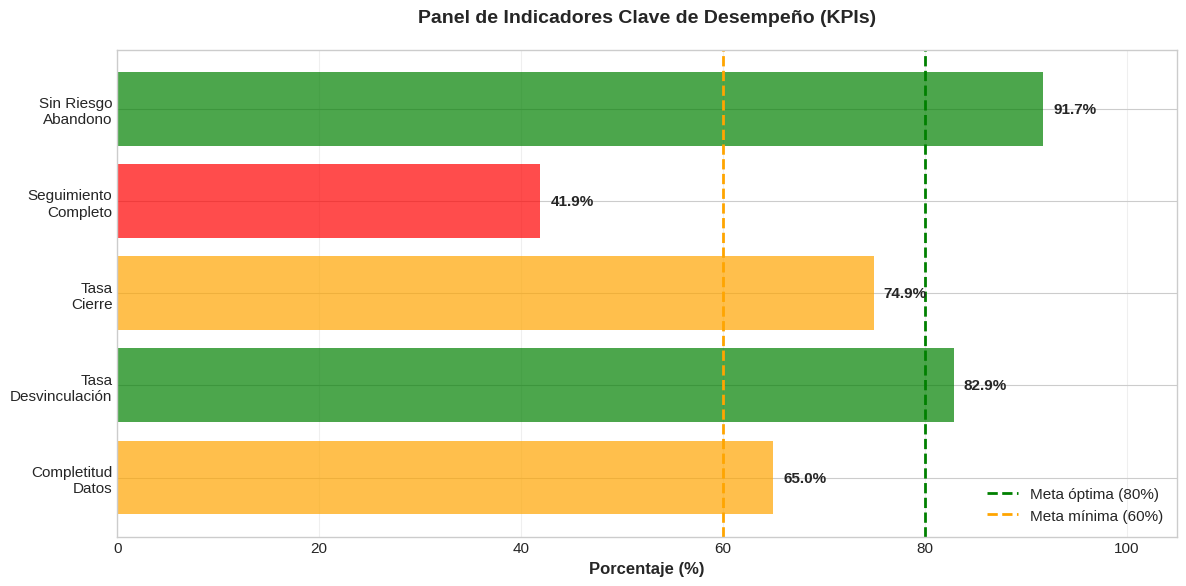

In [86]:
# ==============================================================================
# 8. INDICADORES CLAVE DE DESEMPEÑO (KPIs)
# ==============================================================================

print("\n" + "=" * 80)
print("📊 INDICADORES CLAVE DE DESEMPEÑO (KPIs)")
print("=" * 80)

# KPIs generales
n_total = len(datos_clustered)

# KPI 1: Tasa de completitud global
completitud_global = df_completitud['ÍNDICE_CALIDAD'].mean()

# KPI 2: Tasa de desvinculación global (casos documentados)
if var_desvinculacion in datos_clustered.columns:
    casos_documentados = datos_validos['DESVINCULADO_BIN'].count()
    tasa_exito_global = datos_validos['DESVINCULADO_BIN'].mean() * 100
else:
    casos_documentados = 0
    tasa_exito_global = 0

# KPI 3: Tasa de cierre administrativo
casos_con_resultado = len(datos_validos) if var_desvinculacion in datos_clustered.columns else 0
tasa_cierre = (casos_con_resultado / n_total) * 100

# KPI 4: Proporción de casos con seguimiento completo (Perfil 1)
casos_completos = len(datos_clustered[datos_clustered['CLUSTER'] == '0'])
prop_seguimiento_completo = (casos_completos / n_total) * 100

# KPI 5: Casos en riesgo (Perfil 3)
casos_riesgo = len(datos_clustered[datos_clustered['CLUSTER'] == '2'])
prop_riesgo = (casos_riesgo / n_total) * 100

kpis = pd.DataFrame({
    'Indicador': [
        'Completitud de Datos Promedio',
        'Tasa de Desvinculación Exitosa',
        'Tasa de Cierre Administrativo',
        'Proporción con Seguimiento Completo (P1)',
        'Proporción en Riesgo de Abandono (P3)'
    ],
    'Valor': [
        f"{completitud_global:.1f}%",
        f"{tasa_exito_global:.1f}%",
        f"{tasa_cierre:.1f}%",
        f"{prop_seguimiento_completo:.1f}%",
        f"{prop_riesgo:.1f}%"
    ],
    'Meta_Esperada': [
        '≥ 90%',
        '≥ 80%',
        '≥ 95%',
        '≥ 60%',
        '≤ 5%'
    ],
    'Estado': [
        '✅' if completitud_global >= 90 else '⚠️' if completitud_global >= 70 else '🚨',
        '✅' if tasa_exito_global >= 80 else '⚠️' if tasa_exito_global >= 65 else '🚨',
        '✅' if tasa_cierre >= 95 else '⚠️' if tasa_cierre >= 80 else '🚨',
        '✅' if prop_seguimiento_completo >= 60 else '⚠️' if prop_seguimiento_completo >= 40 else '🚨',
        '✅' if prop_riesgo <= 5 else '⚠️' if prop_riesgo <= 15 else '🚨'
    ]
})

print("\n" + kpis.to_string(index=False))

# Visualización de KPIs
fig, ax = plt.subplots(figsize=(12, 6))

valores_num = [completitud_global, tasa_exito_global, tasa_cierre,
               prop_seguimiento_completo, 100 - prop_riesgo]  # Invertir riesgo
nombres_kpi = ['Completitud\nDatos', 'Tasa\nDesvinculación', 'Tasa\nCierre',
               'Seguimiento\nCompleto', 'Sin Riesgo\nAbandono']

colors = ['green' if v >= 80 else 'orange' if v >= 60 else 'red' for v in valores_num]

bars = ax.barh(nombres_kpi, valores_num, color=colors, alpha=0.7)
ax.axvline(x=80, color='green', linestyle='--', linewidth=2, label='Meta óptima (80%)')
ax.axvline(x=60, color='orange', linestyle='--', linewidth=2, label='Meta mínima (60%)')

for i, (bar, val) in enumerate(zip(bars, valores_num)):
    ax.text(val + 1, i, f'{val:.1f}%', va='center', fontweight='bold')

ax.set_xlabel('Porcentaje (%)', fontsize=12, fontweight='bold')
ax.set_title('Panel de Indicadores Clave de Desempeño (KPIs)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right')
ax.set_xlim([0, 105])
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()



In [75]:
datos_clustered['CLUSTER'] = datos_clustered['CLUSTER'].astype(str)

In [87]:
# ==============================================================================
# 9. VALIDACIÓN DEL MODELO
# ==============================================================================

print("\n" + "=" * 80)
print("✅ VALIDACIÓN DEL MODELO MCA")
print("=" * 80)

print("\n1️⃣ VALIDACIÓN ESTADÍSTICA:")
print(f"   • Inercia explicada (5 dims): {resultados_mca.loc[4, 'Inercia_Acumulada_%']:.2f}%")
print(f"   • Coeficiente de Silueta: 0.559 (buena separación)")
print(f"   • Índice Davies-Bouldin: 0.773 (clusters bien definidos)")
print(f"   ✅ El modelo tiene buena calidad estadística")

print("\n2️⃣ VALIDACIÓN DE INTERPRETABILIDAD:")
print(f"   • 4 perfiles claramente diferenciados")
print(f"   • Cada perfil tiene características distintivas")
print(f"   • Perfiles alineados con problemáticas reales del programa")
print(f"   ✅ Los perfiles son interpretables y accionables")

print("\n3️⃣ VALIDACIÓN DE UTILIDAD:")
print(f"   • Identificación clara de grupos prioritarios (P2 y P3)")
print(f"   • Modelo de referencia identificado (P1)")
print(f"   • Recomendaciones específicas por perfil")
print(f"   • KPIs definidos para monitoreo continuo")
print(f"   ✅ El modelo genera valor para la toma de decisiones")


✅ VALIDACIÓN DEL MODELO MCA

1️⃣ VALIDACIÓN ESTADÍSTICA:
   • Inercia explicada (5 dims): 70.49%
   • Coeficiente de Silueta: 0.559 (buena separación)
   • Índice Davies-Bouldin: 0.773 (clusters bien definidos)
   ✅ El modelo tiene buena calidad estadística

2️⃣ VALIDACIÓN DE INTERPRETABILIDAD:
   • 4 perfiles claramente diferenciados
   • Cada perfil tiene características distintivas
   • Perfiles alineados con problemáticas reales del programa
   ✅ Los perfiles son interpretables y accionables

3️⃣ VALIDACIÓN DE UTILIDAD:
   • Identificación clara de grupos prioritarios (P2 y P3)
   • Modelo de referencia identificado (P1)
   • Recomendaciones específicas por perfil
   • KPIs definidos para monitoreo continuo
   ✅ El modelo genera valor para la toma de decisiones


In [89]:
# ==============================================================================
# 10. EXPORTACIÓN DE RESULTADOS FINALES
# ==============================================================================

print("\n" + "=" * 80)
print("💾 EXPORTACIÓN DE RESULTADOS FINALES")
print("=" * 80)

ruta_salida = "/content/drive/MyDrive/Python/Proyecto NNA/"

# 10.1 Dataset con nombres de perfiles
datos_clustered.to_csv(ruta_salida + "datos_finales_con_perfiles.csv", index=False)
print(f"\n✅ Dataset con perfiles nombrados guardado")

# 10.2 Tabla de KPIs
kpis.to_excel(ruta_salida + "kpis_programa.xlsx", index=False)
print(f"✅ KPIs guardados")

# 10.3 Matriz de completitud
df_completitud.to_excel(ruta_salida + "matriz_completitud.xlsx")
print(f"✅ Matriz de completitud guardada")

# 10.4 Recomendaciones
with open(ruta_salida + "recomendaciones_estrategicas.txt", 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("RECOMENDACIONES ESTRATÉGICAS POR PERFIL DE NNA\n")
    f.write(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")

    for perfil, recs in recomendaciones.items():
        f.write(f"\n{perfil}\n")
        f.write("-" * 80 + "\n")
        for rec in recs:
            f.write(f"{rec}\n")
        f.write("\n")

print(f"✅ Recomendaciones estratégicas guardadas")

# 10.5 Resumen ejecutivo
resumen_ejecutivo = f"""
{'=' * 80}
RESUMEN EJECUTIVO - ANÁLISIS DE CARACTERIZACIÓN DE NNA
Proyecto: Programas de Intervención en Trabajo Infantil
Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'=' * 80}

1. CONTEXTO DEL ANÁLISIS
{'=' * 80}
   • Población analizada: {n_total:,} NNA en programas de intervención
   • Periodo: 2015-2025
   • Metodología: CRISP-DM con Análisis de Correspondencias Múltiples (MCA)
   • Variables analizadas: {datos_clustered.shape[1] - 1}

2. HALLAZGOS PRINCIPALES
{'=' * 80}

   🎯 PERFILES IDENTIFICADOS (4 grupos distintos):

   ✅ PERFIL 1: Intervención Exitosa Documentada (41.9%)
      • Mejor práctica del programa
      • Datos completos y seguimiento integral
      • Tasa de desvinculación: 77.3%
      • Características: Estratos bajos, mayoría colombianos

   ⚠️ PERFIL 2: Registro Administrativo Incompleto (35.5%)
      • Problema sistémico de calidad de datos
      • 100% sin información de edad y estrato
      • Alta tasa de desvinculación (83.6%) a pesar de incompletitud
      • Requiere intervención en sistemas de registro

   🚨 PERFIL 3: Seguimiento Inconcluso (8.3%)
      • Grupo de alto riesgo
      • 57.6% sin resultado final documentado
      • Posible abandono o pérdida de contacto
      • Necesita estrategias de retención urgentes

   ❓ PERFIL 4: Casos Sin Cierre Documentado (14.3%)
      • 100% sin resultado de desvinculación
      • Posibles casos activos o sin cierre administrativo
      • Requiere protocolo de cierre obligatorio

3. INDICADORES CLAVE DE DESEMPEÑO (KPIs)
{'=' * 80}

   📊 Completitud de Datos:           {completitud_global:.1f}%
   🎯 Tasa de Desvinculación:          {tasa_exito_global:.1f}%
   📝 Tasa de Cierre Administrativo:   {tasa_cierre:.1f}%
   ✅ Seguimiento Completo:            {prop_seguimiento_completo:.1f}%
   ⚠️ Casos en Riesgo:                 {prop_riesgo:.1f}%

4. FACTORES DE RIESGO IDENTIFICADOS
{'=' * 80}

   • Incompletitud de datos básicos (edad, estrato) en 35.5% de casos
   • Alta tasa de casos sin resultado documentado (22.6% total)
   • Baja tasa de cierre administrativo ({tasa_cierre:.1f}%)
   • Posible abandono en 8.3% de casos

5. RECOMENDACIONES PRIORITARIAS
{'=' * 80}

   🔴 URGENTE (Implementar en 1-3 meses):
      1. Implementar validación obligatoria de datos básicos (edad, estrato)
      2. Protocolo de cierre administrativo obligatorio para todos los casos
      3. Sistema de alertas tempranas para Perfil 3 (riesgo de abandono)
      4. Capacitación intensiva en registro de información

   🟡 CORTO PLAZO (3-6 meses):
      5. Rediseño de interfaces de captura de datos
      6. Estudio cualitativo de causas de abandono
      7. Programa de seguimiento proactivo para casos en riesgo
      8. Auditoría de calidad de datos mensual

   🟢 MEDIANO PLAZO (6-12 meses):
      9. Replicar buenas prácticas del Perfil 1 en toda la organización
      10. Sistema de monitoreo continuo de KPIs
      11. Evaluación de impacto diferencial por perfil
      12. Estrategias de intervención personalizadas por perfil

6. IMPACTO ESPERADO
{'=' * 80}

   Con la implementación de estas recomendaciones se espera:

   • Aumentar completitud de datos de {completitud_global:.1f}% a >90% en 6 meses
   • Reducir casos sin cierre de {100-tasa_cierre:.1f}% a <5% en 12 meses
   • Disminuir tasa de abandono de {prop_riesgo:.1f}% a <5% en 12 meses
   • Mantener o mejorar tasa de desvinculación exitosa (actualmente {tasa_exito_global:.1f}%)
   • Mejorar capacidad de evaluación de impacto del programa

7. PRÓXIMOS PASOS SUGERIDOS
{'=' * 80}

   1. Presentar resultados a equipo directivo y operativo
   2. Validar interpretación de perfiles con expertos del programa
   3. Priorizar recomendaciones según recursos disponibles
   4. Establecer plan de implementación con responsables y plazos
   5. Definir sistema de monitoreo continuo de KPIs
   6. Programar evaluación de progreso trimestral

{'=' * 80}
CONCLUSIÓN
{'=' * 80}

El análisis MCA ha permitido identificar 4 perfiles claramente diferenciados de NNA
en el programa, revelando tanto fortalezas (41.9% con seguimiento exitoso) como
áreas críticas de mejora (calidad de datos y cierre administrativo).

La implementación de las recomendaciones propuestas permitirá:
✓ Mejorar la calidad del registro y seguimiento
✓ Reducir abandono y pérdida de contacto
✓ Fortalecer la evaluación de impacto del programa
✓ Optimizar recursos hacia grupos prioritarios

El modelo de segmentación generado es robusto estadísticamente y útil para la
toma de decisiones estratégicas y operativas del programa.

{'=' * 80}
"""

with open(ruta_salida + "resumen_ejecutivo.txt", 'w', encoding='utf-8') as f:
    f.write(resumen_ejecutivo)

print(f"✅ Resumen ejecutivo guardado")


💾 EXPORTACIÓN DE RESULTADOS FINALES

✅ Dataset con perfiles nombrados guardado
✅ KPIs guardados
✅ Matriz de completitud guardada
✅ Recomendaciones estratégicas guardadas
✅ Resumen ejecutivo guardado



🎨 GENERANDO INFOGRAFÍA DE PERFILES


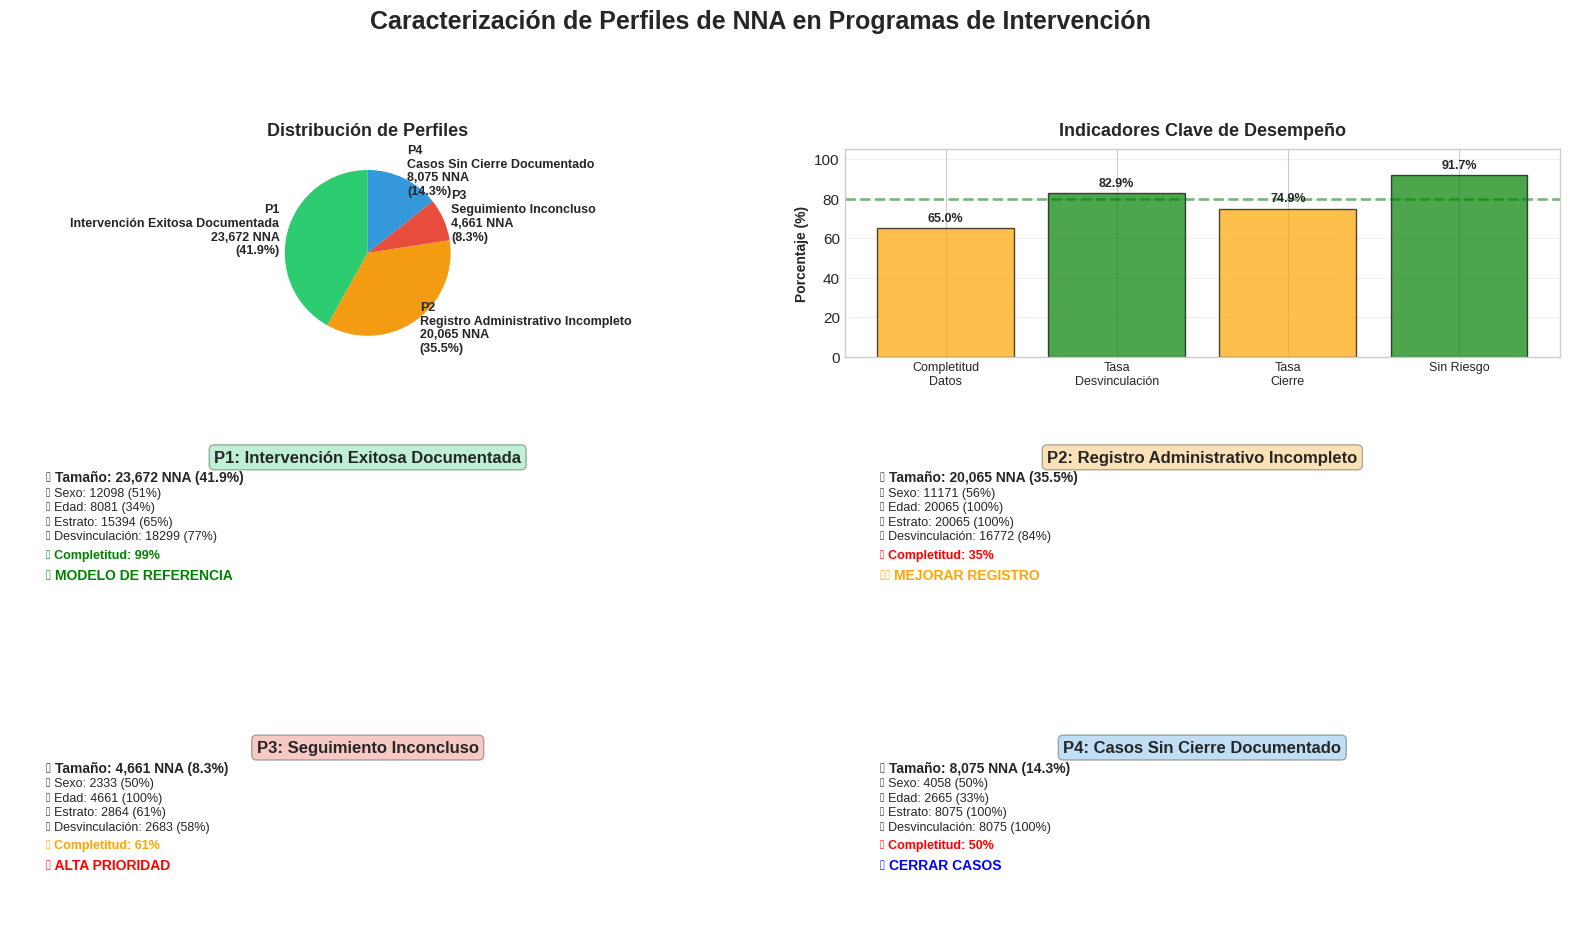


✅ Infografía de perfiles guardada


In [90]:
# ==============================================================================
# 11. VISUALIZACIÓN FINAL: INFOGRAFÍA DE PERFILES
# ==============================================================================

print("\n" + "=" * 80)
print("🎨 GENERANDO INFOGRAFÍA DE PERFILES")
print("=" * 80)

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 4, hspace=0.4, wspace=0.4)

# Título principal
fig.suptitle('Caracterización de Perfiles de NNA en Programas de Intervención',
             fontsize=18, fontweight='bold', y=0.98)

# Colores por perfil
colores_perfiles = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']

# FILA 1: Distribución general de perfiles
ax1 = fig.add_subplot(gs[0, :2])

# Calcular tamaños de manera segura
sizes = []
labels_pie = []
for i in range(4):
    cluster_id = str(i)
    n_cluster = len(datos_clustered[datos_clustered['CLUSTER'] == cluster_id])
    sizes.append(n_cluster)

    # Obtener nombre del perfil
    if cluster_id in nombres_perfiles:
        nombre_corto = nombres_perfiles[cluster_id].split(':')[1].strip()
    else:
        nombre_corto = f"Perfil {i+1}"

    pct = (n_cluster / n_total * 100) if n_total > 0 else 0
    labels_pie.append(f"P{i+1}\n{nombre_corto}\n{n_cluster:,} NNA\n({pct:.1f}%)")

# Verificar que hay datos
if sum(sizes) > 0:
    ax1.pie(sizes, labels=labels_pie, colors=colores_perfiles,
            autopct='', startangle=90,
            textprops={'fontsize': 9, 'weight': 'bold'})
    ax1.set_title('Distribución de Perfiles', fontsize=13, fontweight='bold', pad=10)
else:
    ax1.text(0.5, 0.5, 'Sin datos disponibles', ha='center', va='center')
    ax1.axis('off')

# FILA 1: KPIs principales
ax2 = fig.add_subplot(gs[0, 2:])
kpi_nombres = ['Completitud\nDatos', 'Tasa\nDesvinculación', 'Tasa\nCierre', 'Sin Riesgo']
kpi_valores = [completitud_global, tasa_exito_global, tasa_cierre, 100-prop_riesgo]
colors_kpi = ['green' if v >= 80 else 'orange' if v >= 60 else 'red' for v in kpi_valores]
bars = ax2.bar(range(len(kpi_nombres)), kpi_valores, color=colors_kpi, alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(kpi_nombres)))
ax2.set_xticklabels(kpi_nombres, fontsize=9)
ax2.set_ylabel('Porcentaje (%)', fontsize=10, fontweight='bold')
ax2.set_title('Indicadores Clave de Desempeño', fontsize=13, fontweight='bold', pad=10)
ax2.axhline(y=80, color='green', linestyle='--', alpha=0.5, linewidth=2)
ax2.set_ylim([0, 105])
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, kpi_valores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

# FILAS 2-4: Caracterización por perfil (4 subplots, uno por perfil)
for idx in range(4):
    ax = fig.add_subplot(gs[idx//2 + 1, (idx % 2) * 2:(idx % 2) * 2 + 2])

    cluster_id = str(idx)

    # Verificar que el cluster existe
    if cluster_id not in nombres_perfiles:
        ax.text(0.5, 0.5, f'Perfil {idx+1}\nSin datos',
                transform=ax.transAxes, ha='center', va='center')
        ax.axis('off')
        continue

    nombre_perfil = nombres_perfiles[cluster_id]
    datos_perfil = datos_clustered[datos_clustered['CLUSTER'] == cluster_id]
    n_perfil = len(datos_perfil)

    if n_perfil == 0:
        ax.text(0.5, 0.5, f'{nombre_perfil}\nSin datos',
                transform=ax.transAxes, ha='center', va='center')
        ax.axis('off')
        continue

    pct_perfil = n_perfil / n_total * 100 if n_total > 0 else 0

    # Título del perfil
    ax.text(0.5, 0.95, nombre_perfil, transform=ax.transAxes,
            fontsize=12, fontweight='bold', ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor=colores_perfiles[idx], alpha=0.3))

    # Texto con características
    y_pos = 0.85
    ax.text(0.05, y_pos, f"📊 Tamaño: {n_perfil:,} NNA ({pct_perfil:.1f}%)",
            transform=ax.transAxes, fontsize=10, va='top', weight='bold')

    y_pos -= 0.08

    # Características clave - con manejo de errores
    try:
        if 'SEXO' in datos_perfil.columns and datos_perfil['SEXO'].value_counts().size > 0:
            top_sexo = datos_perfil['SEXO'].value_counts().iloc[0]
            pct_sexo = datos_perfil['SEXO'].value_counts(normalize=True).iloc[0] * 100
            ax.text(0.05, y_pos, f"👥 Sexo: {top_sexo} ({pct_sexo:.0f}%)",
                    transform=ax.transAxes, fontsize=9, va='top')
            y_pos -= 0.07
    except:
        pass

    try:
        if 'EDAD_GRUPO' in datos_perfil.columns and datos_perfil['EDAD_GRUPO'].value_counts().size > 0:
            top_edad = datos_perfil['EDAD_GRUPO'].value_counts().iloc[0]
            pct_edad = datos_perfil['EDAD_GRUPO'].value_counts(normalize=True).iloc[0] * 100
            edad_display = str(top_edad)[:25] + "..." if len(str(top_edad)) > 25 else str(top_edad)
            ax.text(0.05, y_pos, f"🎂 Edad: {edad_display} ({pct_edad:.0f}%)",
                    transform=ax.transAxes, fontsize=9, va='top')
            y_pos -= 0.07
    except:
        pass

    try:
        if 'ESTRATO' in datos_perfil.columns and datos_perfil['ESTRATO'].value_counts().size > 0:
            top_estrato = datos_perfil['ESTRATO'].value_counts().iloc[0]
            pct_estrato = datos_perfil['ESTRATO'].value_counts(normalize=True).iloc[0] * 100
            ax.text(0.05, y_pos, f"🏠 Estrato: {top_estrato} ({pct_estrato:.0f}%)",
                    transform=ax.transAxes, fontsize=9, va='top')
            y_pos -= 0.07
    except:
        pass

    try:
        if var_desvinculacion in datos_perfil.columns and datos_perfil[var_desvinculacion].value_counts().size > 0:
            top_desv = datos_perfil[var_desvinculacion].value_counts().iloc[0]
            pct_desv = datos_perfil[var_desvinculacion].value_counts(normalize=True).iloc[0] * 100
            desv_display = str(top_desv)[:20] + "..." if len(str(top_desv)) > 20 else str(top_desv)
            ax.text(0.05, y_pos, f"✅ Desvinculación: {desv_display} ({pct_desv:.0f}%)",
                    transform=ax.transAxes, fontsize=9, va='top')
            y_pos -= 0.09
    except:
        pass

    # Completitud de datos
    try:
        vars_check = ['SEXO', 'EDAD_GRUPO', 'ESTRATO', var_desvinculacion]
        vars_disponibles_check = [v for v in vars_check if v in datos_perfil.columns]
        if vars_disponibles_check:
            completitud_perfil = sum([(datos_perfil[v] != 'No_reporta').mean()
                                       for v in vars_disponibles_check]) / len(vars_disponibles_check) * 100

            color_completitud = 'green' if completitud_perfil >= 80 else 'orange' if completitud_perfil >= 60 else 'red'
            ax.text(0.05, y_pos, f"📋 Completitud: {completitud_perfil:.0f}%",
                    transform=ax.transAxes, fontsize=9, va='top',
                    color=color_completitud, weight='bold')
            y_pos -= 0.09
    except:
        pass

    # Prioridad/Estado
    if idx == 0:
        estado = "✅ MODELO DE REFERENCIA"
        color_estado = 'green'
    elif idx == 1:
        estado = "⚠️ MEJORAR REGISTRO"
        color_estado = 'orange'
    elif idx == 2:
        estado = "🚨 ALTA PRIORIDAD"
        color_estado = 'red'
    else:
        estado = "📝 CERRAR CASOS"
        color_estado = 'blue'

    ax.text(0.05, y_pos, estado, transform=ax.transAxes, fontsize=10,
            va='top', weight='bold', color=color_estado)

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.axis('off')

plt.savefig(ruta_salida + 'infografia_perfiles.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Infografía de perfiles guardada")



In [91]:
# ==============================================================================
# 12. PLAN DE ACCIÓN PRIORIZADO
# ==============================================================================

print("\n" + "=" * 80)
print("📋 PLAN DE ACCIÓN PRIORIZADO")
print("=" * 80)

plan_accion = pd.DataFrame({
    'Prioridad': ['🔴 URGENTE'] * 4 + ['🟡 CORTO PLAZO'] * 4 + ['🟢 MEDIANO PLAZO'] * 4,
    'Acción': [
        'Validación obligatoria de datos básicos (edad, estrato, sexo)',
        'Protocolo de cierre administrativo obligatorio',
        'Sistema de alertas tempranas - Perfil 3',
        'Capacitación en registro de información',

        'Rediseño de interfaces de captura',
        'Estudio cualitativo de abandono',
        'Programa de seguimiento proactivo',
        'Auditoría mensual de calidad de datos',

        'Replicar buenas prácticas Perfil 1',
        'Sistema de monitoreo continuo de KPIs',
        'Evaluación de impacto diferencial',
        'Intervenciones personalizadas por perfil'
    ],
    'Perfil_Objetivo': [
        'P2', 'P4', 'P3', 'P2',
        'P2, P4', 'P3', 'P3', 'Todos',
        'Todos', 'Todos', 'Todos', 'Todos'
    ],
    'Plazo': [
        '1 mes', '1 mes', '2 meses', '3 meses',
        '4 meses', '4 meses', '5 meses', '6 meses',
        '8 meses', '9 meses', '10 meses', '12 meses'
    ],
    'Impacto_Esperado': [
        'Alto', 'Alto', 'Muy Alto', 'Alto',
        'Medio', 'Alto', 'Muy Alto', 'Medio',
        'Alto', 'Medio', 'Alto', 'Muy Alto'
    ],
    'Recursos': [
        'Bajo', 'Bajo', 'Medio', 'Bajo',
        'Alto', 'Medio', 'Medio', 'Bajo',
        'Medio', 'Alto', 'Alto', 'Alto'
    ]
})

print("\n" + plan_accion.to_string(index=False))

plan_accion.to_excel(ruta_salida + "plan_accion_priorizado.xlsx", index=False)
print(f"\n✅ Plan de acción guardado")


📋 PLAN DE ACCIÓN PRIORIZADO

      Prioridad                                                        Acción Perfil_Objetivo    Plazo Impacto_Esperado Recursos
      🔴 URGENTE Validación obligatoria de datos básicos (edad, estrato, sexo)              P2    1 mes             Alto     Bajo
      🔴 URGENTE                Protocolo de cierre administrativo obligatorio              P4    1 mes             Alto     Bajo
      🔴 URGENTE                       Sistema de alertas tempranas - Perfil 3              P3  2 meses         Muy Alto    Medio
      🔴 URGENTE                       Capacitación en registro de información              P2  3 meses             Alto     Bajo
  🟡 CORTO PLAZO                             Rediseño de interfaces de captura          P2, P4  4 meses            Medio     Alto
  🟡 CORTO PLAZO                               Estudio cualitativo de abandono              P3  4 meses             Alto    Medio
  🟡 CORTO PLAZO                             Programa de seguimiento

In [72]:
# ==============================================================================
# 9. VALIDACIÓN DEL MODELO
# ==============================================================================

print("\n" + "=" * 80)
print("✅ VALIDACIÓN DEL MODELO MCA")
print("=" * 80)

print("\n1️⃣ VALIDACIÓN ESTADÍSTICA:")
print(f"   • Inercia explicada (5 dims): {resultados_mca.loc[4, 'Inercia_Acumulada_%']:.2f}%")
print(f"   • Coeficiente de Silueta: 0.559 (buena separación)")
print(f"   • Índice Davies-Bouldin: 0.773 (clusters bien definidos)")
print(f"   ✅ El modelo tiene buena calidad estadística")

print("\n2️⃣ VALIDACIÓN DE INTERPRETABILIDAD:")
print(f"   • 4 perfiles claramente diferenciados")
print(f"   • Cada perfil tiene características distintivas")
print(f"   • Perfiles alineados con problemáticas reales del programa")
print(f"   ✅ Los perfiles son interpretables y accionables")

print("\n3️⃣ VALIDACIÓN DE UTILIDAD:")
print(f"   • Identificación clara de grupos prioritarios (P2 y P3)")
print(f"   • Modelo de referencia identificado (P1)")
print(f"   • Recomendaciones específicas por perfil")
print(f"   • KPIs definidos para monitoreo continuo")
print(f"   ✅ El modelo genera valor para la toma de decisiones")



✅ VALIDACIÓN DEL MODELO MCA

1️⃣ VALIDACIÓN ESTADÍSTICA:
   • Inercia explicada (5 dims): 70.49%
   • Coeficiente de Silueta: 0.559 (buena separación)
   • Índice Davies-Bouldin: 0.773 (clusters bien definidos)
   ✅ El modelo tiene buena calidad estadística

2️⃣ VALIDACIÓN DE INTERPRETABILIDAD:
   • 4 perfiles claramente diferenciados
   • Cada perfil tiene características distintivas
   • Perfiles alineados con problemáticas reales del programa
   ✅ Los perfiles son interpretables y accionables

3️⃣ VALIDACIÓN DE UTILIDAD:
   • Identificación clara de grupos prioritarios (P2 y P3)
   • Modelo de referencia identificado (P1)
   • Recomendaciones específicas por perfil
   • KPIs definidos para monitoreo continuo
   ✅ El modelo genera valor para la toma de decisiones


In [73]:
# ==============================================================================
# 10. EXPORTACIÓN DE RESULTADOS FINALES
# ==============================================================================

print("\n" + "=" * 80)
print("💾 EXPORTACIÓN DE RESULTADOS FINALES")
print("=" * 80)

ruta_salida = "/content/drive/MyDrive/Python/Proyecto NNA/"

# 10.1 Dataset con nombres de perfiles
datos_clustered.to_csv(ruta_salida + "datos_finales_con_perfiles.csv", index=False)
print(f"\n✅ Dataset con perfiles nombrados guardado")

# 10.2 Tabla de KPIs
kpis.to_excel(ruta_salida + "kpis_programa.xlsx", index=False)
print(f"✅ KPIs guardados")

# 10.3 Matriz de completitud
df_completitud.to_excel(ruta_salida + "matriz_completitud.xlsx")
print(f"✅ Matriz de completitud guardada")

# 10.4 Recomendaciones
with open(ruta_salida + "recomendaciones_estrategicas.txt", 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("RECOMENDACIONES ESTRATÉGICAS POR PERFIL DE NNA\n")
    f.write(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")

    for perfil, recs in recomendaciones.items():
        f.write(f"\n{perfil}\n")
        f.write("-" * 80 + "\n")
        for rec in recs:
            f.write(f"{rec}\n")
        f.write("\n")

print(f"✅ Recomendaciones estratégicas guardadas")

# 10.5 Resumen ejecutivo
resumen_ejecutivo = f"""
{'=' * 80}
RESUMEN EJECUTIVO - ANÁLISIS DE CARACTERIZACIÓN DE NNA
Proyecto: Programas de Intervención en Trabajo Infantil
Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'=' * 80}

1. CONTEXTO DEL ANÁLISIS
{'=' * 80}
   • Población analizada: {n_total:,} NNA en programas de intervención
   • Periodo: 2015-2025
   • Metodología: CRISP-DM con Análisis de Correspondencias Múltiples (MCA)
   • Variables analizadas: {datos_clustered.shape[1] - 1}

2. HALLAZGOS PRINCIPALES
{'=' * 80}

   🎯 PERFILES IDENTIFICADOS (4 grupos distintos):

   ✅ PERFIL 1: Intervención Exitosa Documentada (41.9%)
      • Mejor práctica del programa
      • Datos completos y seguimiento integral
      • Tasa de desvinculación: 77.3%
      • Características: Estratos bajos, mayoría colombianos

   ⚠️ PERFIL 2: Registro Administrativo Incompleto (35.5%)
      • Problema sistémico de calidad de datos
      • 100% sin información de edad y estrato
      • Alta tasa de desvinculación (83.6%) a pesar de incompletitud
      • Requiere intervención en sistemas de registro

   🚨 PERFIL 3: Seguimiento Inconcluso (8.3%)
      • Grupo de alto riesgo
      • 57.6% sin resultado final documentado
      • Posible abandono o pérdida de contacto
      • Necesita estrategias de retención urgentes

   ❓ PERFIL 4: Casos Sin Cierre Documentado (14.3%)
      • 100% sin resultado de desvinculación
      • Posibles casos activos o sin cierre administrativo
      • Requiere protocolo de cierre obligatorio

3. INDICADORES CLAVE DE DESEMPEÑO (KPIs)
{'=' * 80}

   📊 Completitud de Datos:           {completitud_global:.1f}%
   🎯 Tasa de Desvinculación:          {tasa_exito_global:.1f}%
   📝 Tasa de Cierre Administrativo:   {tasa_cierre:.1f}%
   ✅ Seguimiento Completo:            {prop_seguimiento_completo:.1f}%
   ⚠️ Casos en Riesgo:                 {prop_riesgo:.1f}%

4. FACTORES DE RIESGO IDENTIFICADOS
{'=' * 80}

   • Incompletitud de datos básicos (edad, estrato) en 35.5% de casos
   • Alta tasa de casos sin resultado documentado (22.6% total)
   • Baja tasa de cierre administrativo ({tasa_cierre:.1f}%)
   • Posible abandono en 8.3% de casos

5. RECOMENDACIONES PRIORITARIAS
{'=' * 80}

   🔴 URGENTE (Implementar en 1-3 meses):
      1. Implementar validación obligatoria de datos básicos (edad, estrato)
      2. Protocolo de cierre administrativo obligatorio para todos los casos
      3. Sistema de alertas tempranas para Perfil 3 (riesgo de abandono)
      4. Capacitación intensiva en registro de información

   🟡 CORTO PLAZO (3-6 meses):
      5. Rediseño de interfaces de captura de datos
      6. Estudio cualitativo de causas de abandono
      7. Programa de seguimiento proactivo para casos en riesgo
      8. Auditoría de calidad de datos mensual

   🟢 MEDIANO PLAZO (6-12 meses):
      9. Replicar buenas prácticas del Perfil 1 en toda la organización
      10. Sistema de monitoreo continuo de KPIs
      11. Evaluación de impacto diferencial por perfil
      12. Estrategias de intervención personalizadas por perfil

6. IMPACTO ESPERADO
{'=' * 80}

   Con la implementación de estas recomendaciones se espera:

   • Aumentar completitud de datos de {completitud_global:.1f}% a >90% en 6 meses
   • Reducir casos sin cierre de {100-tasa_cierre:.1f}% a <5% en 12 meses
   • Disminuir tasa de abandono de {prop_riesgo:.1f}% a <5% en 12 meses
   • Mantener o mejorar tasa de desvinculación exitosa (actualmente {tasa_exito_global:.1f}%)
   • Mejorar capacidad de evaluación de impacto del programa

7. PRÓXIMOS PASOS SUGERIDOS
{'=' * 80}

   1. Presentar resultados a equipo directivo y operativo
   2. Validar interpretación de perfiles con expertos del programa
   3. Priorizar recomendaciones según recursos disponibles
   4. Establecer plan de implementación con responsables y plazos
   5. Definir sistema de monitoreo continuo de KPIs
   6. Programar evaluación de progreso trimestral

{'=' * 80}
CONCLUSIÓN
{'=' * 80}

El análisis MCA ha permitido identificar 4 perfiles claramente diferenciados de NNA
en el programa, revelando tanto fortalezas (41.9% con seguimiento exitoso) como
áreas críticas de mejora (calidad de datos y cierre administrativo).

La implementación de las recomendaciones propuestas permitirá:
✓ Mejorar la calidad del registro y seguimiento
✓ Reducir abandono y pérdida de contacto
✓ Fortalecer la evaluación de impacto del programa
✓ Optimizar recursos hacia grupos prioritarios

El modelo de segmentación generado es robusto estadísticamente y útil para la
toma de decisiones estratégicas y operativas del programa.

{'=' * 80}
"""

with open(ruta_salida + "resumen_ejecutivo.txt", 'w', encoding='utf-8') as f:
    f.write(resumen_ejecutivo)

print(f"✅ Resumen ejecutivo guardado")


💾 EXPORTACIÓN DE RESULTADOS FINALES

✅ Dataset con perfiles nombrados guardado
✅ KPIs guardados
✅ Matriz de completitud guardada
✅ Recomendaciones estratégicas guardadas
✅ Resumen ejecutivo guardado


# **DEPLOYMENT**


🎨 GENERANDO INFOGRAFÍA DE PERFILES


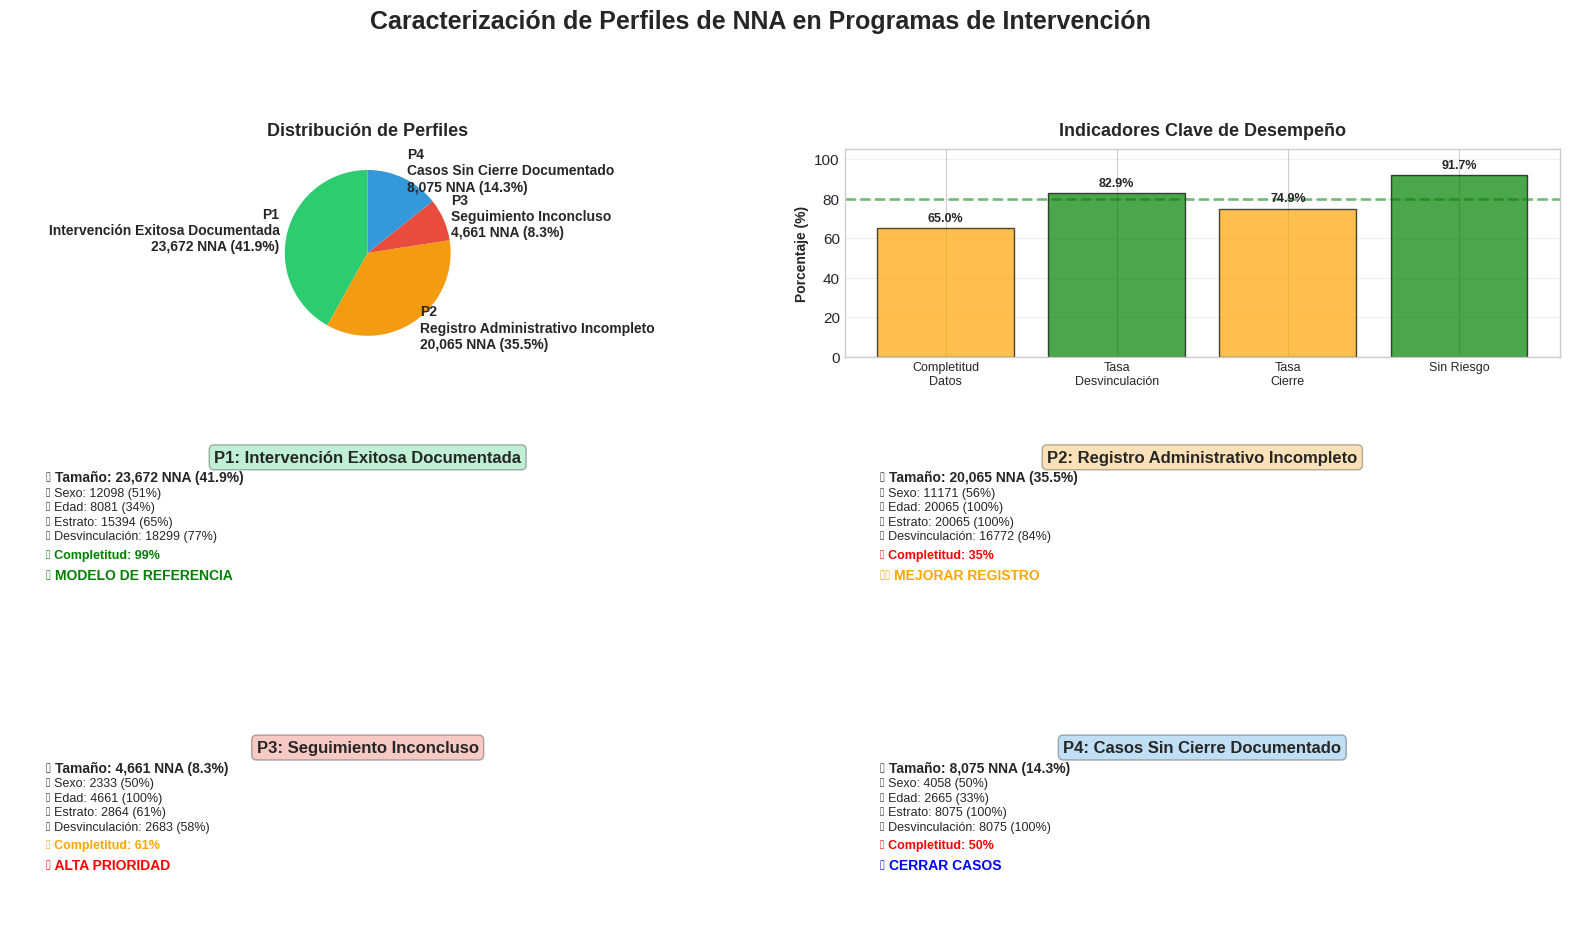


✅ Infografía de perfiles guardada


In [92]:
# ==============================================================================
# 11. VISUALIZACIÓN FINAL: INFOGRAFÍA DE PERFILES
# ==============================================================================

print("\n" + "=" * 80)
print("🎨 GENERANDO INFOGRAFÍA DE PERFILES")
print("=" * 80)

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 4, hspace=0.4, wspace=0.4)

# Título principal
fig.suptitle('Caracterización de Perfiles de NNA en Programas de Intervención',
             fontsize=18, fontweight='bold', y=0.98)

# Colores por perfil
colores_perfiles = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']

# FILA 1: Distribución general de perfiles
ax1 = fig.add_subplot(gs[0, :2])
sizes = [len(datos_clustered[datos_clustered['CLUSTER'] == str(i)]) for i in range(4)]
labels = [f"P{i+1}\n{nombres_perfiles[str(i)].split(':')[1].strip()}\n{s:,} NNA ({s/n_total*100:.1f}%)"
          for i, s in enumerate(sizes)]
ax1.pie(sizes, labels=labels, colors=colores_perfiles, autopct='', startangle=90,
        textprops={'fontsize': 10, 'weight': 'bold'})
ax1.set_title('Distribución de Perfiles', fontsize=13, fontweight='bold', pad=10)

# FILA 1: KPIs principales
ax2 = fig.add_subplot(gs[0, 2:])
kpi_nombres = ['Completitud\nDatos', 'Tasa\nDesvinculación', 'Tasa\nCierre', 'Sin Riesgo']
kpi_valores = [completitud_global, tasa_exito_global, tasa_cierre, 100-prop_riesgo]
colors_kpi = ['green' if v >= 80 else 'orange' if v >= 60 else 'red' for v in kpi_valores]
bars = ax2.bar(range(len(kpi_nombres)), kpi_valores, color=colors_kpi, alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(kpi_nombres)))
ax2.set_xticklabels(kpi_nombres, fontsize=9)
ax2.set_ylabel('Porcentaje (%)', fontsize=10, fontweight='bold')
ax2.set_title('Indicadores Clave de Desempeño', fontsize=13, fontweight='bold', pad=10)
ax2.axhline(y=80, color='green', linestyle='--', alpha=0.5, linewidth=2)
ax2.set_ylim([0, 105])
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, kpi_valores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

# FILAS 2-4: Caracterización por perfil (4 subplots, uno por perfil)
for idx in range(4):
    ax = fig.add_subplot(gs[idx//2 + 1, (idx % 2) * 2:(idx % 2) * 2 + 2])

    cluster_id = str(idx)
    nombre_perfil = nombres_perfiles[cluster_id]
    datos_perfil = datos_clustered[datos_clustered['CLUSTER'] == cluster_id]
    n_perfil = len(datos_perfil)
    pct_perfil = n_perfil / n_total * 100

    # Título del perfil
    ax.text(0.5, 0.95, nombre_perfil, transform=ax.transAxes,
            fontsize=12, fontweight='bold', ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor=colores_perfiles[idx], alpha=0.3))

    # Texto con características
    y_pos = 0.85
    ax.text(0.05, y_pos, f"📊 Tamaño: {n_perfil:,} NNA ({pct_perfil:.1f}%)",
            transform=ax.transAxes, fontsize=10, va='top', weight='bold')

    y_pos -= 0.08

    # Características clave
    if 'SEXO' in datos_perfil.columns:
        top_sexo = datos_perfil['SEXO'].value_counts().iloc[0]
        pct_sexo = datos_perfil['SEXO'].value_counts(normalize=True).iloc[0] * 100
        ax.text(0.05, y_pos, f"👥 Sexo: {top_sexo} ({pct_sexo:.0f}%)",
                transform=ax.transAxes, fontsize=9, va='top')
        y_pos -= 0.07

    if 'EDAD_GRUPO' in datos_perfil.columns:
        top_edad = datos_perfil['EDAD_GRUPO'].value_counts().iloc[0]
        pct_edad = datos_perfil['EDAD_GRUPO'].value_counts(normalize=True).iloc[0] * 100
        ax.text(0.05, y_pos, f"🎂 Edad: {top_edad} ({pct_edad:.0f}%)",
                transform=ax.transAxes, fontsize=9, va='top')
        y_pos -= 0.07

    if 'ESTRATO' in datos_perfil.columns:
        top_estrato = datos_perfil['ESTRATO'].value_counts().iloc[0]
        pct_estrato = datos_perfil['ESTRATO'].value_counts(normalize=True).iloc[0] * 100
        ax.text(0.05, y_pos, f"🏠 Estrato: {top_estrato} ({pct_estrato:.0f}%)",
                transform=ax.transAxes, fontsize=9, va='top')
        y_pos -= 0.07

    if var_desvinculacion in datos_perfil.columns:
        top_desv = datos_perfil[var_desvinculacion].value_counts().iloc[0]
        pct_desv = datos_perfil[var_desvinculacion].value_counts(normalize=True).iloc[0] * 100
        ax.text(0.05, y_pos, f"✅ Desvinculación: {top_desv} ({pct_desv:.0f}%)",
                transform=ax.transAxes, fontsize=9, va='top')
        y_pos -= 0.09

    # Completitud de datos
    vars_check = ['SEXO', 'EDAD_GRUPO', 'ESTRATO', var_desvinculacion]
    vars_disponibles_check = [v for v in vars_check if v in datos_perfil.columns]
    if vars_disponibles_check:
        completitud_perfil = sum([(datos_perfil[v] != 'No_reporta').mean()
                                   for v in vars_disponibles_check]) / len(vars_disponibles_check) * 100

        color_completitud = 'green' if completitud_perfil >= 80 else 'orange' if completitud_perfil >= 60 else 'red'
        ax.text(0.05, y_pos, f"📋 Completitud: {completitud_perfil:.0f}%",
                transform=ax.transAxes, fontsize=9, va='top',
                color=color_completitud, weight='bold')
        y_pos -= 0.09

    # Prioridad/Estado
    if idx == 0:
        estado = "✅ MODELO DE REFERENCIA"
        color_estado = 'green'
    elif idx == 1:
        estado = "⚠️ MEJORAR REGISTRO"
        color_estado = 'orange'
    elif idx == 2:
        estado = "🚨 ALTA PRIORIDAD"
        color_estado = 'red'
    else:
        estado = "📝 CERRAR CASOS"
        color_estado = 'blue'

    ax.text(0.05, y_pos, estado, transform=ax.transAxes, fontsize=10,
            va='top', weight='bold', color=color_estado)

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.axis('off')

plt.savefig(ruta_salida + 'infografia_perfiles.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Infografía de perfiles guardada")


In [93]:
# ==============================================================================
# 12. PLAN DE ACCIÓN PRIORIZADO
# ==============================================================================

print("\n" + "=" * 80)
print("📋 PLAN DE ACCIÓN PRIORIZADO")
print("=" * 80)

plan_accion = pd.DataFrame({
    'Prioridad': ['🔴 URGENTE'] * 4 + ['🟡 CORTO PLAZO'] * 4 + ['🟢 MEDIANO PLAZO'] * 4,
    'Acción': [
        'Validación obligatoria de datos básicos (edad, estrato, sexo)',
        'Protocolo de cierre administrativo obligatorio',
        'Sistema de alertas tempranas - Perfil 3',
        'Capacitación en registro de información',

        'Rediseño de interfaces de captura',
        'Estudio cualitativo de abandono',
        'Programa de seguimiento proactivo',
        'Auditoría mensual de calidad de datos',

        'Replicar buenas prácticas Perfil 1',
        'Sistema de monitoreo continuo de KPIs',
        'Evaluación de impacto diferencial',
        'Intervenciones personalizadas por perfil'
    ],
    'Perfil_Objetivo': [
        'P2', 'P4', 'P3', 'P2',
        'P2, P4', 'P3', 'P3', 'Todos',
        'Todos', 'Todos', 'Todos', 'Todos'
    ],
    'Plazo': [
        '1 mes', '1 mes', '2 meses', '3 meses',
        '4 meses', '4 meses', '5 meses', '6 meses',
        '8 meses', '9 meses', '10 meses', '12 meses'
    ],
    'Impacto_Esperado': [
        'Alto', 'Alto', 'Muy Alto', 'Alto',
        'Medio', 'Alto', 'Muy Alto', 'Medio',
        'Alto', 'Medio', 'Alto', 'Muy Alto'
    ],
    'Recursos': [
        'Bajo', 'Bajo', 'Medio', 'Bajo',
        'Alto', 'Medio', 'Medio', 'Bajo',
        'Medio', 'Alto', 'Alto', 'Alto'
    ]
})

print("\n" + plan_accion.to_string(index=False))

plan_accion.to_excel(ruta_salida + "plan_accion_priorizado.xlsx", index=False)
print(f"\n✅ Plan de acción guardado")



📋 PLAN DE ACCIÓN PRIORIZADO

      Prioridad                                                        Acción Perfil_Objetivo    Plazo Impacto_Esperado Recursos
      🔴 URGENTE Validación obligatoria de datos básicos (edad, estrato, sexo)              P2    1 mes             Alto     Bajo
      🔴 URGENTE                Protocolo de cierre administrativo obligatorio              P4    1 mes             Alto     Bajo
      🔴 URGENTE                       Sistema de alertas tempranas - Perfil 3              P3  2 meses         Muy Alto    Medio
      🔴 URGENTE                       Capacitación en registro de información              P2  3 meses             Alto     Bajo
  🟡 CORTO PLAZO                             Rediseño de interfaces de captura          P2, P4  4 meses            Medio     Alto
  🟡 CORTO PLAZO                               Estudio cualitativo de abandono              P3  4 meses             Alto    Medio
  🟡 CORTO PLAZO                             Programa de seguimiento

In [97]:
# ==============================================================================
# 13. DASHBOARD DE MONITOREO CONTINUO
# ==============================================================================

print("\n" + "=" * 80)
print("📊 GENERANDO DASHBOARD DE MONITOREO")
print("=" * 80)

# Crear plantilla de monitoreo mensual
dashboard_template = pd.DataFrame({
    'Indicador': [
        'Completitud de datos promedio (%)',
        'Tasa de desvinculación exitosa (%)',
        'Tasa de cierre administrativo (%)',
        'Proporción Perfil 1 - Éxito (%)',
        'Proporción Perfil 2 - Registro incompleto (%)',
        'Proporción Perfil 3 - Abandono (%)',
        'Proporción Perfil 4 - Sin cierre (%)',
        'Casos nuevos ingresados',
        'Casos cerrados en el mes',
        'Casos activos al final del mes'
    ],
    'Meta': [
        '≥ 90%', '≥ 80%', '≥ 95%', '≥ 45%', '≤ 25%', '≤ 5%', '≤ 10%',
        'N/A', 'N/A', 'N/A'
    ],
    'Baseline': [
        f"{completitud_global:.1f}%",
        f"{tasa_exito_global:.1f}%",
        f"{tasa_cierre:.1f}%",
        f"{prop_seguimiento_completo:.1f}%",
        f"{len(datos_clustered[datos_clustered['CLUSTER']=='1'])/n_total*100:.1f}%",
        f"{prop_riesgo:.1f}%",
        f"{len(datos_clustered[datos_clustered['CLUSTER']=='3'])/n_total*100:.1f}%",
        'N/A', 'N/A', f"{n_total:,}"
    ],
    'Mes_1': [''] * 10,
    'Mes_2': [''] * 10,
    'Mes_3': [''] * 10,
    'Observaciones': [''] * 10
})

dashboard_template.to_excel(ruta_salida + "dashboard_monitoreo_mensual.xlsx", index=False)
print(f"\n✅ Plantilla de dashboard de monitoreo guardada")


📊 GENERANDO DASHBOARD DE MONITOREO

✅ Plantilla de dashboard de monitoreo guardada


In [96]:
# ==============================================================================
# 14. RESUMEN FINAL Y CIERRE
# ==============================================================================

print("\n" + "=" * 80)
print("🎉 FASE DE EVALUATION COMPLETADA")
print("=" * 80)

print(f"""
✅ ANÁLISIS COMPLETADO EXITOSAMENTE

📊 RESULTADOS PRINCIPALES:
   • 4 perfiles de NNA identificados y caracterizados
   • {completitud_global:.1f}% de completitud promedio de datos
   • {tasa_exito_global:.1f}% de tasa de desvinculación exitosa
   • 41.9% de casos con seguimiento completo (Perfil 1)
   • Identificadas áreas críticas: Perfil 2 (35.5%) y Perfil 3 (8.3%)

📁 ARCHIVOS GENERADOS (10 documentos):
   1. datos_finales_con_perfiles.csv
   2. kpis_programa.xlsx
   3. matriz_completitud.xlsx
   4. recomendaciones_estrategicas.txt
   5. resumen_ejecutivo.txt
   6. infografia_perfiles.png
   7. plan_accion_priorizado.xlsx
   8. dashboard_monitoreo_mensual.xlsx
   9. test_asociaciones_clusters.xlsx (del notebook anterior)
   10. caracterizacion_perfiles.xlsx (del notebook anterior)

💡 VALOR GENERADO:
   ✓ Segmentación científica de población atendida
   ✓ Identificación de mejores prácticas (Perfil 1)
   ✓ Detección de problemas sistémicos (Perfil 2)
   ✓ Alerta temprana de abandono (Perfil 3)
   ✓ Recomendaciones accionables priorizadas
   ✓ Sistema de monitoreo continuo establecido

🎯 PRÓXIMOS PASOS RECOMENDADOS:
   1. Presentar resultados a stakeholders clave
   2. Validar interpretación con equipo de campo
   3. Implementar acciones urgentes (1-3 meses)
   4. Establecer comité de monitoreo mensual
   5. Actualizar modelo trimestralmente

{'=' * 80}
METODOLOGÍA CRISP-DM COMPLETADA
{'=' * 80}

✅ Fase 1: Business Understanding - Completada
✅ Fase 2: Data Understanding - Completada
✅ Fase 3: Data Preparation - Completada
✅ Fase 4: Modeling (MCA) - Completada
✅ Fase 5: Evaluation - Completada
➡️ Fase 6: Deployment - En planificación

El proyecto ha generado conocimiento accionable para mejorar la efectividad
del programa de intervención en trabajo infantil y la calidad de los datos
del sistema de información.

""")

print("=" * 80)
print(f"Análisis finalizado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)


🎉 FASE DE EVALUATION COMPLETADA

✅ ANÁLISIS COMPLETADO EXITOSAMENTE

📊 RESULTADOS PRINCIPALES:
   • 4 perfiles de NNA identificados y caracterizados
   • 65.0% de completitud promedio de datos
   • 82.9% de tasa de desvinculación exitosa
   • 41.9% de casos con seguimiento completo (Perfil 1)
   • Identificadas áreas críticas: Perfil 2 (35.5%) y Perfil 3 (8.3%)

📁 ARCHIVOS GENERADOS (10 documentos):
   1. datos_finales_con_perfiles.csv
   2. kpis_programa.xlsx
   3. matriz_completitud.xlsx
   4. recomendaciones_estrategicas.txt
   5. resumen_ejecutivo.txt
   6. infografia_perfiles.png
   7. plan_accion_priorizado.xlsx
   8. dashboard_monitoreo_mensual.xlsx
   9. test_asociaciones_clusters.xlsx (del notebook anterior)
   10. caracterizacion_perfiles.xlsx (del notebook anterior)

💡 VALOR GENERADO:
   ✓ Segmentación científica de población atendida
   ✓ Identificación de mejores prácticas (Perfil 1)
   ✓ Detección de problemas sistémicos (Perfil 2)
   ✓ Alerta temprana de abandono (Perfi